# Feature Engineering

In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
os.chdir("..")

## Заргузка данных

In [7]:
DATA_PATH = "data/interim/monthly_sales.parquet"

df = pd.read_parquet(DATA_PATH)
df = df.sort_values(["shop_id", "date_block_num", "item_id"], ascending=[True, True, True])

month_mapping = df[['date_block_num', 'year', 'month']].drop_duplicates().set_index('date_block_num')
items_static = df[['item_id', 'item_name', 'item_category_id', 
                   'item_category_name', 'main_category', 'super_category']].drop_duplicates()
shops_static = df[['shop_id', 'shop_name']].drop_duplicates()

# Функция заполнения
def fill_shop(group):
    items = group['item_id'].unique()
    months = range(group['date_block_num'].min(), group['date_block_num'].max() + 1)
    idx = pd.MultiIndex.from_product([items, months], names=['item_id', 'date_block_num'])
    temp = group[['item_id', 'date_block_num', 'item_cnt_month', 'avg_price']].set_index(['item_id', 'date_block_num'])
    full = temp.reindex(idx).reset_index()
    full['shop_id'] = group['shop_id'].iloc[0]
    full['item_cnt_month'] = full['item_cnt_month'].fillna(0)
    full = full.sort_values(['shop_id', 'item_id', 'date_block_num'])
    full['avg_price'] = full.groupby(['shop_id', 'item_id'])['avg_price'].ffill()
    return full

filled_dfs = []
for shop_id, group in df.groupby('shop_id'):
    filled_dfs.append(fill_shop(group))

full_df = pd.concat(filled_dfs, ignore_index=True)

full_df = full_df.merge(month_mapping, on='date_block_num', how='left')
full_df = full_df.merge(items_static, on='item_id', how='left')
full_df = full_df.merge(shops_static, on='shop_id', how='left')

full_df = full_df[df.columns]

full_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,main_category,super_category,shop_name
0,0,2013,1,2,27,1.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега"""
1,1,2013,2,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега"""
2,2,2013,3,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега"""
3,3,2013,4,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега"""
4,4,2013,5,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега"""


## Проверка данных

In [8]:
full_df.shape

(13157758, 13)

In [9]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13157758 entries, 0 to 13157757
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date_block_num      int64  
 1   year                int32  
 2   month               int32  
 3   shop_id             int64  
 4   item_id             int64  
 5   item_cnt_month      float64
 6   avg_price           float64
 7   item_name           object 
 8   item_category_id    int64  
 9   item_category_name  object 
 10  main_category       object 
 11  super_category      object 
 12  shop_name           object 
dtypes: float64(2), int32(2), int64(4), object(5)
memory usage: 1.2+ GB


In [11]:
full_df.duplicated().sum()

np.int64(0)

In [12]:
full_df.isna().sum()

date_block_num              0
year                        0
month                       0
shop_id                     0
item_id                     0
item_cnt_month              0
avg_price             4095129
item_name                   0
item_category_id            0
item_category_name          0
main_category               0
super_category              0
shop_name                   0
dtype: int64

## Лаговые признаки

In [16]:
TARGET_COL = "item_cnt_month"

group_key = ["shop_id", "item_id"]
sales = full_df.groupby(group_key, sort=False)[TARGET_COL]

full_df["lag_1"] = sales.shift(1)
full_df["lag_2"] = sales.shift(2)
full_df["lag_3"] = sales.shift(3)
full_df["lag_6"] = sales.shift(6)
full_df["lag_12"] = sales.shift(12)
full_df["pred_hist_avg"] = sales.transform(lambda s: s.shift(1).expanding().mean())

full_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,main_category,super_category,shop_name,lag_1,lag_2,lag_3,lag_6,lag_12,pred_hist_avg
0,0,2013,1,2,27,1.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013,2,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",1.0,NaN,NaN,NaN,NaN,1.000000
2,2,2013,3,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",0.0,1.0,NaN,NaN,NaN,0.500000
3,3,2013,4,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",0.0,0.0,1.0,NaN,NaN,0.333333
4,4,2013,5,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,Игры,Игры,"Адыгея ТЦ ""Мега""",0.0,0.0,0.0,NaN,NaN,0.250000


## Скользящие признаки

In [18]:
full_df["item_cnt_roll_mean_3"] = sales.transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

full_df["item_cnt_roll_mean_6"] = sales.transform(
    lambda s: s.shift(1).rolling(6, min_periods=1).mean()
)

full_df["item_cnt_roll_mean_12"] = sales.transform(
    lambda s: s.shift(1).rolling(12, min_periods=1).mean()
)

full_df["item_cnt_roll_std_3"] = sales.transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).std()
)

full_df["item_cnt_roll_std_6"] = sales.transform(
    lambda s: s.shift(1).rolling(6, min_periods=1).std()
)

full_df["item_cnt_roll_max_3"] = sales.transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).max()
)

full_df["item_cnt_roll_min_3"] = sales.transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).min()
)

full_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,...,lag_6,lag_12,pred_hist_avg,item_cnt_roll_mean_3,item_cnt_roll_mean_6,item_cnt_roll_mean_12,item_cnt_roll_std_3,item_cnt_roll_std_6,item_cnt_roll_max_3,item_cnt_roll_min_3
0,0,2013,1,2,27,1.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013,2,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.0,1.0
2,2,2013,3,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,0.500000,0.500000,0.500000,0.500000,0.707107,0.707107,1.0,0.0
3,3,2013,4,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,0.333333,0.333333,0.333333,0.333333,0.577350,0.577350,1.0,0.0
4,4,2013,5,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,0.250000,0.000000,0.250000,0.250000,0.000000,0.500000,0.0,0.0


## Ценовые признаки

In [19]:
PRICE_COL = "avg_price"

group_key = ["shop_id", "item_id"]
sales_prices = full_df.groupby(group_key, sort=False)[PRICE_COL]

full_df["price_lag_1"] = sales_prices.shift(1)
full_df["price_lag_2"] = sales_prices.shift(2)
full_df["price_change"] = full_df["avg_price"] - full_df["price_lag_1"]
full_df["item_avg_price_roll_mean_3"] = sales_prices.transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

full_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,...,item_cnt_roll_mean_6,item_cnt_roll_mean_12,item_cnt_roll_std_3,item_cnt_roll_std_6,item_cnt_roll_max_3,item_cnt_roll_min_3,price_lag_1,price_lag_2,price_change,item_avg_price_roll_mean_3
0,0,2013,1,2,27,1.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013,2,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,1.000000,1.000000,NaN,NaN,1.0,1.0,2499.0,NaN,0.0,2499.0
2,2,2013,3,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.500000,0.500000,0.707107,0.707107,1.0,0.0,2499.0,2499.0,0.0,2499.0
3,3,2013,4,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.333333,0.333333,0.577350,0.577350,1.0,0.0,2499.0,2499.0,0.0,2499.0
4,4,2013,5,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.250000,0.250000,0.000000,0.500000,0.0,0.0,2499.0,2499.0,0.0,2499.0


## Календарные признаки

In [20]:
full_df["month_sin"] = np.sin(2 * np.pi * full_df["month"] / 12)
full_df["month_cos"] = np.cos(2 * np.pi * full_df["month"] / 12)

full_df["is_summer"] = full_df["month"].isin([6,7,8]).astype(int)
full_df["is_winter"] = full_df["month"].isin([1, 2, 12]).astype(int)

full_df["days_in_month"] = full_df["month"].map({
    1:31, 2:28, 3:31, 4:30,
    5:31, 6:30, 7:31, 8:31,
    9:30, 10:31, 11:30, 12:31
})

full_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,...,item_cnt_roll_min_3,price_lag_1,price_lag_2,price_change,item_avg_price_roll_mean_3,month_sin,month_cos,is_summer,is_winter,days_in_month
0,0,2013,1,2,27,1.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,0,1,31
1,1,2013,2,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,1.0,2499.0,NaN,0.0,2499.0,0.866025,5.000000e-01,0,1,28
2,2,2013,3,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.0,2499.0,2499.0,0.0,2499.0,1.000000,6.123234e-17,0,0,31
3,3,2013,4,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.0,2499.0,2499.0,0.0,2499.0,0.866025,-5.000000e-01,0,0,30
4,4,2013,5,2,27,0.0,2499.0,"007 Legends [PS3, русская версия]",19,Игры - PS3,...,0.0,2499.0,2499.0,0.0,2499.0,0.500000,-8.660254e-01,0,0,31


## Кодирование категориальных переменных

Будут удалены лишние переменные, которые полностью дублируют другие
Категориальные переменные будут закодированы с помощью TargetEncoding

In [ ]:
encoded_df = full_df.sort_values('date_block_num').copy()

In [44]:
encoded_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_name,item_category_id,item_category_name,...,item_cnt_roll_min_3,price_lag_1,price_lag_2,price_change,item_avg_price_roll_mean_3,month_sin,month_cos,is_summer,is_winter,days_in_month
6902851,0,2013,1,31,11122,3.0,149.0,ДОБРОЕ УТРО (регион),40,Кино - DVD,...,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0,1,31
10803713,0,2013,1,51,15841,0.0,NaN,НЮХАЧ,40,Кино - DVD,...,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0,1,31
3076688,0,2013,1,18,2356,0.0,NaN,"Castlevania: Lords of Shadow 2 [Xbox 360, русс...",23,Игры - XBOX 360,...,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0,1,31
7178399,0,2013,1,32,3556,0.0,NaN,Forza Motorsport 4 [Xbox 360],23,Игры - XBOX 360,...,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0,1,31
2698084,0,2013,1,16,5528,0.0,NaN,POPPIXIE. ВЫПУСК 7,40,Кино - DVD,...,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,0,1,31


In [46]:
encoded_df = encoded_df.drop(columns=['item_category_name', 'item_name',
                                      'shop_name'])

encoded_df.columns

Index(['date_block_num', 'year', 'month', 'shop_id', 'item_id',
       'item_cnt_month', 'avg_price', 'item_category_id', 'main_category',
       'super_category', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
       'pred_hist_avg', 'item_cnt_roll_mean_3', 'item_cnt_roll_mean_6',
       'item_cnt_roll_mean_12', 'item_cnt_roll_std_3', 'item_cnt_roll_std_6',
       'item_cnt_roll_max_3', 'item_cnt_roll_min_3', 'price_lag_1',
       'price_lag_2', 'price_change', 'item_avg_price_roll_mean_3',
       'month_sin', 'month_cos', 'is_summer', 'is_winter', 'days_in_month'],
      dtype='object')

In [ ]:
cat_features = ['shop_id', 'item_id', 'item_category_id', 'main_category', 'super_category']

# вычисляем агрегированные target_enc для каждой категории
agg_dict = {}
for cat in cat_features:
    # Агрегируем средний target по месяцу и категории
    agg = encoded_df.groupby(['date_block_num', cat])[TARGET_COL].mean().reset_index()
    
    agg[f'{cat}_target_enc'] = agg.groupby(cat)[TARGET_COL].transform(
        lambda s: s.shift(1).expanding().mean()
    )
    
    global_means = (
        agg.groupby('date_block_num')[TARGET_COL]
        .mean()
        .expanding()
        .mean()
        .shift(1)
    )
    agg[f'{cat}_target_enc'] = agg[f'{cat}_target_enc'].fillna(
        agg['date_block_num'].map(global_means)
    )
    
    agg_dict[cat] = agg[['date_block_num', cat, f'{cat}_target_enc']]

for cat in cat_features:
    s = agg_dict[cat].set_index(['date_block_num', cat])[f'{cat}_target_enc']
    encoded_df = encoded_df.join(s, on=['date_block_num', cat], how='left', rsuffix='_tmp')
    encoded_df[f'{cat}_target_enc'] = encoded_df[f'{cat}_target_enc_tmp']
    encoded_df.drop(columns=[f'{cat}_target_enc_tmp'], inplace=True)

In [57]:
encoded_df.head()

,date_block_num,year,month,shop_id,item_id,item_cnt_month,avg_price,item_category_id,main_category,super_category,...,month_sin,month_cos,is_summer,is_winter,days_in_month,shop_id_target_enc,item_id_target_enc,item_category_id_target_enc,main_category_target_enc,super_category_target_enc
6902851,0,2013,1,31,11122,3.0,149.0,40,Кино,Кино,...,0.5,0.866025,0,1,31,NaN,NaN,NaN,NaN,NaN
10803713,0,2013,1,51,15841,0.0,NaN,40,Кино,Кино,...,0.5,0.866025,0,1,31,NaN,NaN,NaN,NaN,NaN
3076688,0,2013,1,18,2356,0.0,NaN,23,Игры,Игры,...,0.5,0.866025,0,1,31,NaN,NaN,NaN,NaN,NaN
7178399,0,2013,1,32,3556,0.0,NaN,23,Игры,Игры,...,0.5,0.866025,0,1,31,NaN,NaN,NaN,NaN,NaN
2698084,0,2013,1,16,5528,0.0,NaN,40,Кино,Кино,...,0.5,0.866025,0,1,31,NaN,NaN,NaN,NaN,NaN


In [59]:
encoded_df = encoded_df.drop(columns=cat_features)
encoded_df.columns

Index(['date_block_num', 'year', 'month', 'item_cnt_month', 'avg_price',
       'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'pred_hist_avg',
       'item_cnt_roll_mean_3', 'item_cnt_roll_mean_6', 'item_cnt_roll_mean_12',
       'item_cnt_roll_std_3', 'item_cnt_roll_std_6', 'item_cnt_roll_max_3',
       'item_cnt_roll_min_3', 'price_lag_1', 'price_lag_2', 'price_change',
       'item_avg_price_roll_mean_3', 'month_sin', 'month_cos', 'is_summer',
       'is_winter', 'days_in_month', 'shop_id_target_enc',
       'item_id_target_enc', 'item_category_id_target_enc',
       'main_category_target_enc', 'super_category_target_enc'],
      dtype='object')

## Уменьшение датасета
Первые 12 месяцев отсекаются, т.к не имеют lag_12

In [64]:
res_df = encoded_df[encoded_df['date_block_num'] >= 13].copy()

## График корреляции

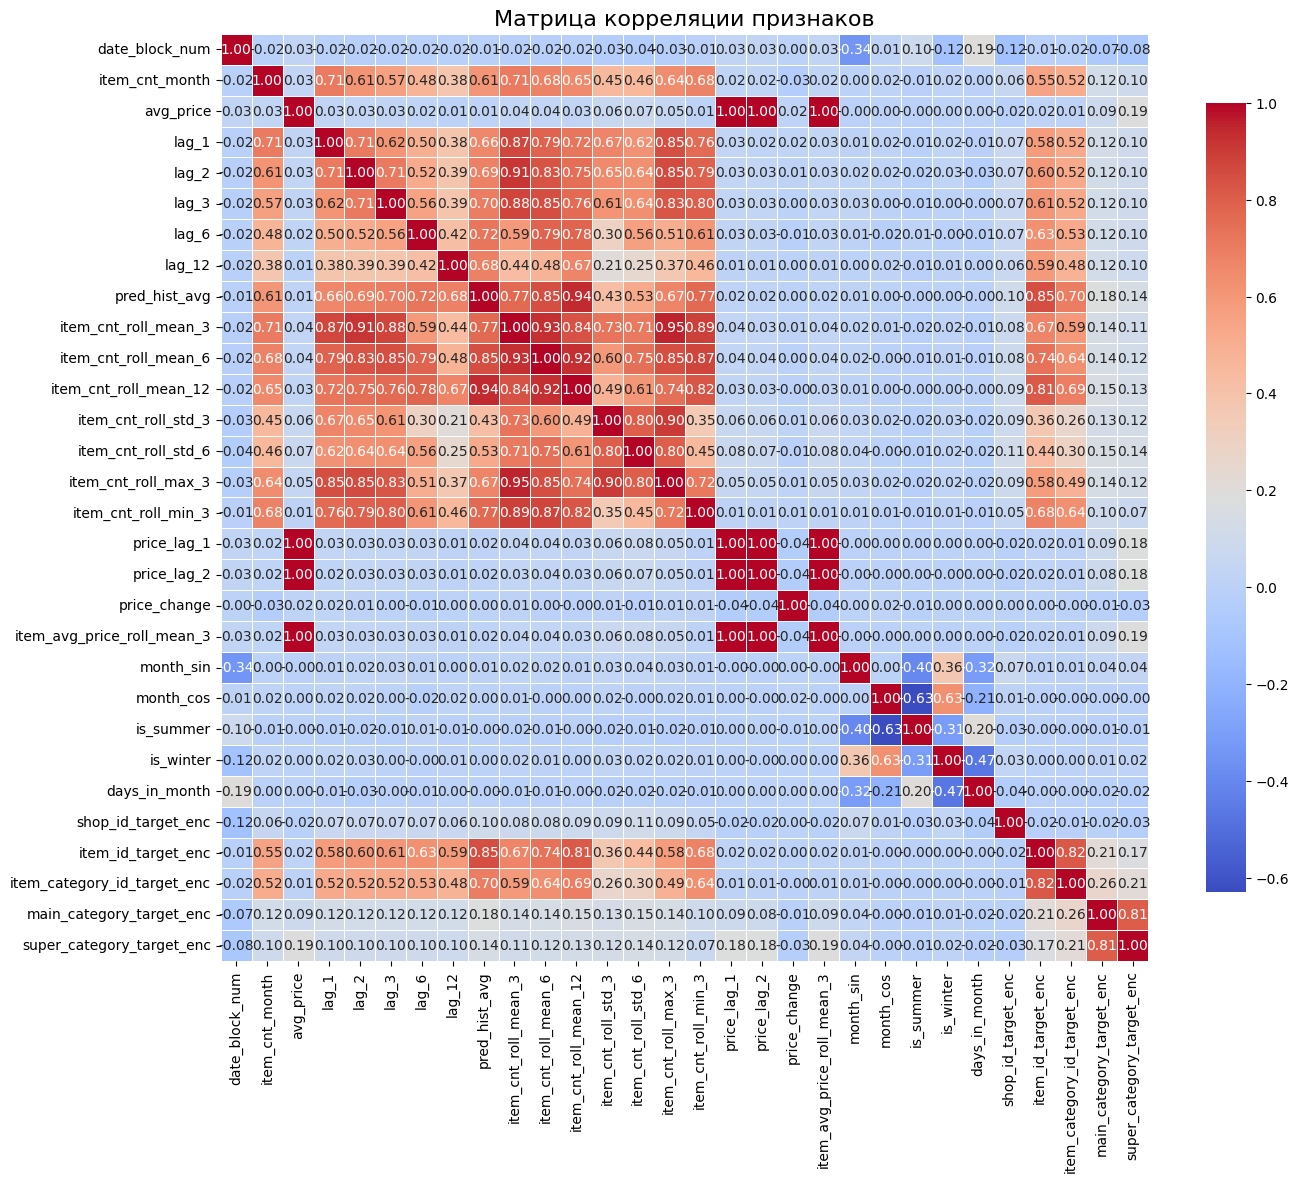

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = res_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

corr = res_df[numerical_cols].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    annot=True,           
    cmap='coolwarm',     
    fmt='.2f',            
    linewidths=0.5,       
    square=True,         
    cbar_kws={"shrink": 0.8}  
)

plt.title('Матрица корреляции признаков', fontsize=16)
plt.tight_layout()        

plt.savefig('artifacts/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Сохранение датасета

In [68]:
res_df.to_parquet("data/processed/model_dataset.parquet",
                  index = False)